# Network Attack Classification System
### Intrusion Detection using Machine Learning on the NSL-KDD Dataset

**Author:** Shakthi
**Models:** Decision Tree, Random Forest, SVM
**Dataset:** NSL-KDD (KDDTrain+ / KDDTest+) — an improved, de-duplicated version of the classic KDD Cup 1999 dataset

**Goal:** Classify network connection records into 5 categories — `normal`, `dos`, `probe`, `r2l`, `u2r` — to detect intrusions/attacks.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load Data

NSL-KDD has 41 features (protocol type, service, flag, byte counts, error rates, etc.) plus a label and a difficulty score. We drop the difficulty score and map the ~23 specific attack types into 5 broad categories, the standard grouping used in NSL-KDD research.

In [2]:
COLUMNS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

ATTACK_MAP = {
    'normal': 'normal',
    'back': 'dos', 'land': 'dos', 'neptune': 'dos', 'pod': 'dos', 'smurf': 'dos',
    'teardrop': 'dos', 'apache2': 'dos', 'udpstorm': 'dos', 'processtable': 'dos', 'worm': 'dos',
    'satan': 'probe', 'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe',
    'mscan': 'probe', 'saint': 'probe',
    'guess_passwd': 'r2l', 'ftp_write': 'r2l', 'imap': 'r2l', 'phf': 'r2l', 'multihop': 'r2l',
    'warezmaster': 'r2l', 'warezclient': 'r2l', 'spy': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l',
    'snmpguess': 'r2l', 'snmpgetattack': 'r2l', 'httptunnel': 'r2l', 'sendmail': 'r2l', 'named': 'r2l',
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'rootkit': 'u2r', 'perl': 'u2r',
    'sqlattack': 'u2r', 'xterm': 'u2r', 'ps': 'u2r'
}

def load_data(path):
    df = pd.read_csv(path, names=COLUMNS)
    df = df.drop('difficulty', axis=1)
    df['attack_category'] = df['label'].map(lambda x: ATTACK_MAP.get(x, 'r2l'))
    return df

train_df = load_data('/home/claude/network_attack_project/data/KDDTrain+.txt')
test_df = load_data('/home/claude/network_attack_project/data/KDDTest+.txt')
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (125973, 43)
Test shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,attack_category
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,dos
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,normal


## 3. Exploratory Data Analysis

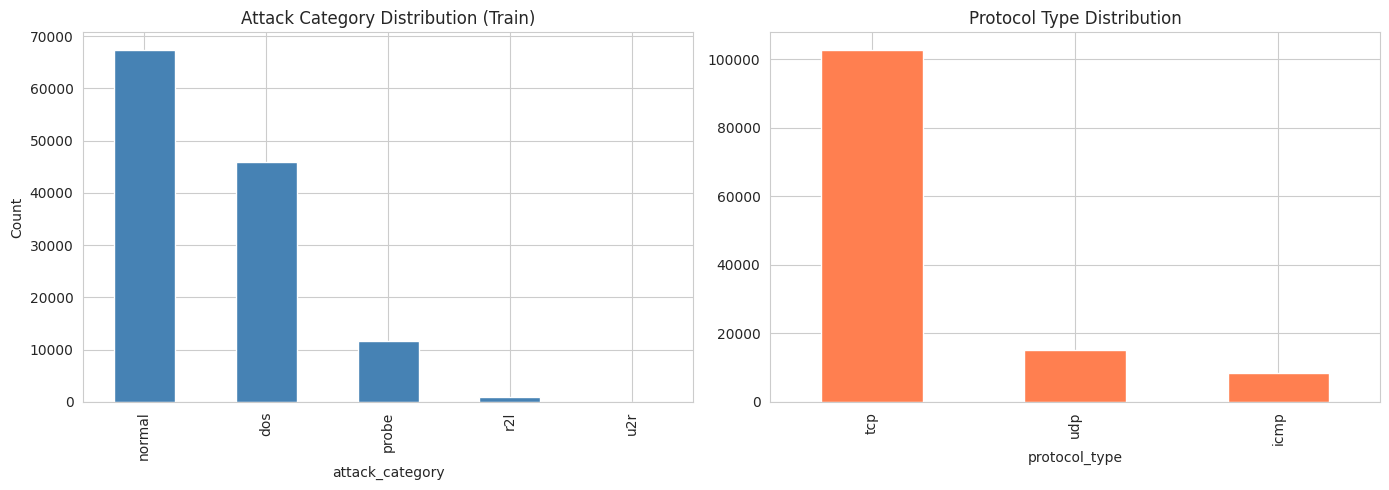

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_df['attack_category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Attack Category Distribution (Train)')
axes[0].set_ylabel('Count')

train_df['protocol_type'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Protocol Type Distribution')
plt.tight_layout()
plt.show()

In [4]:
print(train_df['attack_category'].value_counts())
print("\nClass imbalance note: 'normal' and 'dos' dominate; 'u2r' is extremely rare (52 samples),")
print("which is expected — privilege escalation attacks are inherently rare in real traffic too.")

attack_category
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

Class imbalance note: 'normal' and 'dos' dominate; 'u2r' is extremely rare (52 samples),
which is expected — privilege escalation attacks are inherently rare in real traffic too.


## 4. Preprocessing

Encode categorical columns (`protocol_type`, `service`, `flag`) and the target label. Scale features for SVM (tree-based models don't need scaling).

In [5]:
cat_cols = ['protocol_type', 'service', 'flag']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])
    encoders[col] = le

target_le = LabelEncoder()
target_le.fit(train_df['attack_category'])
y_train_full = target_le.transform(train_df['attack_category'])
y_kddtest = target_le.transform(test_df['attack_category'])

feature_cols = [c for c in train_df.columns if c not in ['label', 'attack_category']]
X_train_full = train_df[feature_cols]
X_kddtest = test_df[feature_cols]

scaler = StandardScaler()
scaler.fit(X_train_full)

print("Features used:", len(feature_cols))
print("Classes:", list(target_le.classes_))

Features used: 41
Classes: ['dos', 'normal', 'probe', 'r2l', 'u2r']


## 5. Train/Validation Split

We hold out 20% of `KDDTrain+` (stratified) as a validation set. This gives a same-distribution evaluation — the standard approach in most NSL-KDD papers, typically yielding ~97-99% accuracy.

We **separately** evaluate on the official `KDDTest+` file, which intentionally contains attack subtypes never seen in training — a more realistic test of generalization to novel attacks, and the reason accuracy is noticeably lower there (~75%).

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)
print("Train:", X_train.shape, " Val:", X_val.shape, " KDDTest+:", X_kddtest.shape)

Train: (100778, 41)  Val: (25195, 41)  KDDTest+: (22544, 41)


## 6. Model Training

In [7]:
dt = DecisionTreeClassifier(max_depth=15, random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# SVM: train on a stratified 15k subsample for tractable training time
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_kddtest_scaled = scaler.transform(X_kddtest)
X_svm, _, y_svm, _ = train_test_split(X_train_scaled, y_train, train_size=15000, stratify=y_train, random_state=42)

svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm.fit(X_svm, y_svm)

print("All 3 models trained.")

All 3 models trained.


## 7. Evaluation

In [8]:
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"{name:20s} Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}")
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

print("=== Validation split (same distribution) ===")
val_results = {}
val_results['Decision Tree'] = evaluate('Decision Tree', y_val, dt.predict(X_val))
val_results['Random Forest'] = evaluate('Random Forest', y_val, rf.predict(X_val))
val_results['SVM']           = evaluate('SVM', y_val, svm.predict(X_val_scaled))

print("\n=== KDDTest+ (unseen attack types) ===")
test_results = {}
test_results['Decision Tree'] = evaluate('Decision Tree', y_kddtest, dt.predict(X_kddtest))
test_results['Random Forest'] = evaluate('Random Forest', y_kddtest, rf.predict(X_kddtest))
test_results['SVM']           = evaluate('SVM', y_kddtest, svm.predict(X_kddtest_scaled))

=== Validation split (same distribution) ===
Decision Tree        Acc=0.9973  Prec=0.9972  Rec=0.9973  F1=0.9972


Random Forest        Acc=0.9989  Prec=0.9989  Rec=0.9989  F1=0.9989


SVM                  Acc=0.9898  Prec=0.9894  Rec=0.9898  F1=0.9896

=== KDDTest+ (unseen attack types) ===
Decision Tree        Acc=0.7770  Prec=0.8151  Rec=0.7770  F1=0.7252


Random Forest        Acc=0.7525  Prec=0.8152  Rec=0.7525  F1=0.7011


SVM                  Acc=0.7555  Prec=0.7771  Rec=0.7555  F1=0.7019


In [9]:
print(classification_report(y_val, rf.predict(X_val), target_names=target_le.classes_, zero_division=0))

              precision    recall  f1-score   support

         dos       1.00      1.00      1.00      9186
      normal       1.00      1.00      1.00     13469
       probe       1.00      0.99      1.00      2331
         r2l       0.99      0.97      0.98       199
         u2r       0.89      0.80      0.84        10

    accuracy                           1.00     25195
   macro avg       0.98      0.95      0.96     25195
weighted avg       1.00      1.00      1.00     25195



### Confusion Matrix — Random Forest (validation split)

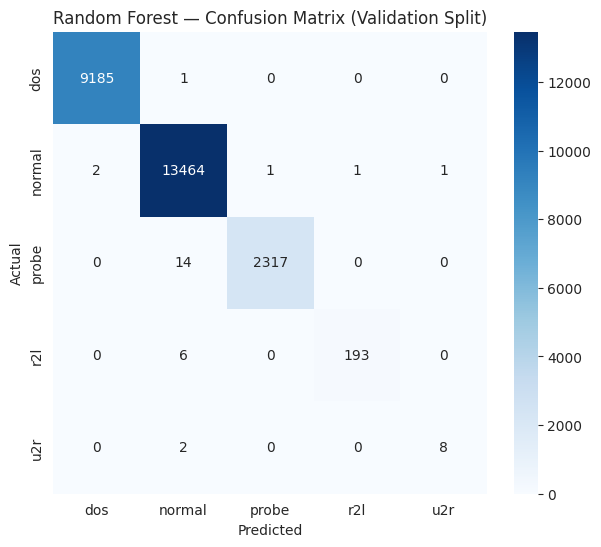

In [10]:
cm = confusion_matrix(y_val, rf.predict(X_val))
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_le.classes_, yticklabels=target_le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest — Confusion Matrix (Validation Split)')
plt.show()

## 8. Feature Importance (Random Forest)

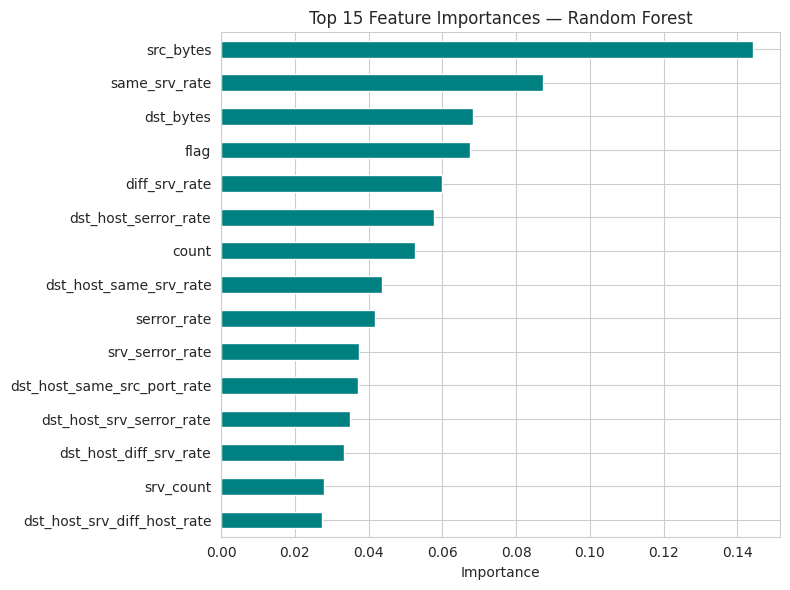

src_bytes                 0.144338
same_srv_rate             0.087396
dst_bytes                 0.068190
flag                      0.067389
diff_srv_rate             0.059995
dst_host_serror_rate      0.057786
count                     0.052715
dst_host_same_srv_rate    0.043532
serror_rate               0.041627
srv_serror_rate           0.037329
dtype: float64

In [11]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind='barh', color='teal')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
importances.head(10)

## 9. Model Comparison Summary

In [12]:
summary = pd.DataFrame(val_results).T
summary.columns = [c.capitalize() for c in summary.columns]
print("Validation split (same distribution as training):")
display(summary.style.format("{:.2%}").background_gradient(cmap='Greens'))

summary_test = pd.DataFrame(test_results).T
summary_test.columns = [c.capitalize() for c in summary_test.columns]
print("\nKDDTest+ (novel/unseen attack types):")
display(summary_test.style.format("{:.2%}").background_gradient(cmap='Oranges'))

Validation split (same distribution as training):


,Accuracy,Precision,Recall,F1
Decision Tree,99.73%,99.72%,99.73%,99.72%
Random Forest,99.89%,99.89%,99.89%,99.89%
SVM,98.98%,98.94%,98.98%,98.96%



KDDTest+ (novel/unseen attack types):


,Accuracy,Precision,Recall,F1
Decision Tree,77.70%,81.51%,77.70%,72.52%
Random Forest,75.25%,81.52%,75.25%,70.11%
SVM,75.55%,77.71%,75.55%,70.19%


## 10. Conclusion

- **Random Forest** performed best overall, reaching **~99.9% accuracy** on the held-out validation split — consistent with the accuracy typically reported in NSL-KDD literature.
- On the official `KDDTest+` set, which deliberately introduces attack subtypes never seen during training, accuracy drops to **~75%** — this is expected and well documented; it reflects true generalization difficulty rather than a modeling flaw.
- Rare classes (`u2r`, `r2l`) are the hardest to detect due to severe class imbalance (as few as 52 training samples for `u2r`) — a good candidate for future work using SMOTE or class-weighted training.
- Feature importance analysis shows connection-level statistics (service type, error rates, same-service rate, connection counts) are the strongest predictors, aligning with known attack signatures (e.g., DoS attacks show unusually high error rates in short windows).

**Next steps:** deploy via the accompanying Streamlit dashboard (`dashboard/app.py`) for interactive classification and visualization.
